### Ideas
- see the grayscale value of the image 
- regression model based on grayscale on the image

#### Explore xml file

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tree = ET.parse("annotations.xml")
root = tree.getroot()

for child in root:
    print(child.tag, child.attrib)

version {}
meta {}
track {'id': '0', 'label': 'planktonic', 'source': 'manual', 'group_id': '25'}
track {'id': '1', 'label': 'planktonic', 'source': 'manual', 'group_id': '24'}
track {'id': '2', 'label': 'planktonic', 'source': 'manual', 'group_id': '24'}
track {'id': '3', 'label': 'planktonic', 'source': 'manual'}
track {'id': '4', 'label': 'planktonic', 'source': 'manual'}
track {'id': '5', 'label': 'planktonic', 'source': 'manual', 'group_id': '26'}
track {'id': '6', 'label': 'planktonic', 'source': 'manual', 'group_id': '26'}
track {'id': '7', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '8', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '9', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '10', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '11', 'label': 'planktonic', 'source': 'manual', 'group_id': '28'}
track {'id': '12', 'label': 'planktonic', 'source': 'manual', 'grou

In [3]:
# From the annotations.xml, start = 0, stop = 40
# For every frame, how many different types of cells respectively
tree = ET.parse("annotations.xml")
root = tree.getroot()

meta = root.find("meta/task")
start_frame = int(meta.find("start_frame").text)
stop_frame  = int(meta.find("stop_frame").text)

frame_counts = {f: {} for f in range(start_frame, stop_frame+1)}

for track in root.findall("track"):
    label = track.attrib["label"]
    for shape in track:
        if shape.attrib.get("outside") == "0":
            f = int(shape.attrib["frame"])
            if label not in frame_counts[f]:
                frame_counts[f][label] = 0
            frame_counts[f][label] += 1

        
print(frame_counts)


{0: {'planktonic': 22}, 1: {'planktonic': 22, 'hyphae': 6}, 2: {'planktonic': 27, 'hyphae': 9}, 3: {'planktonic': 25, 'hyphae': 12}, 4: {'planktonic': 25, 'hyphae': 13}, 5: {'planktonic': 28, 'hyphae': 18}, 6: {'planktonic': 22, 'hyphae': 24}, 7: {'planktonic': 18, 'hyphae': 28}, 8: {'planktonic': 10, 'hyphae': 30, 'biofilm': 2}, 9: {'planktonic': 12, 'hyphae': 42, 'biofilm': 2}, 10: {'hyphae': 31, 'planktonic': 7, 'biofilm': 2}, 11: {'planktonic': 5, 'hyphae': 27, 'biofilm': 3}, 12: {'planktonic': 8, 'hyphae': 25, 'biofilm': 3}, 13: {'planktonic': 8, 'hyphae': 23, 'biofilm': 2}, 14: {'planktonic': 8, 'hyphae': 17, 'biofilm': 2}, 15: {'planktonic': 3, 'single dispersed cell': 1, 'hyphae': 17, 'biofilm': 2}, 16: {'single dispersed cell': 11, 'planktonic': 3, 'hyphae': 13, 'biofilm': 3}, 17: {'hyphae': 6, 'planktonic': 3, 'single dispersed cell': 23, 'biofilm': 3}, 18: {'single dispersed cell': 53, 'biofilm': 3, 'planktonic': 4, 'hyphae': 4}, 19: {'single dispersed cell': 81, 'planktonic

In [4]:
rows = []
for f, counts in frame_counts.items():
    row = {"frame": f, "n_total": sum(counts.values())}
    for label, num in counts.items():
        row[f"n_{label.replace(' ', '_')}"] = num
    rows.append(row)
df = pd.DataFrame(rows).fillna(0).sort_values("frame")
print(df)


    frame  n_total  n_planktonic  n_hyphae  n_biofilm  n_single_dispersed_cell
0       0       22          22.0       0.0        0.0                      0.0
1       1       28          22.0       6.0        0.0                      0.0
2       2       36          27.0       9.0        0.0                      0.0
3       3       37          25.0      12.0        0.0                      0.0
4       4       38          25.0      13.0        0.0                      0.0
5       5       46          28.0      18.0        0.0                      0.0
6       6       46          22.0      24.0        0.0                      0.0
7       7       46          18.0      28.0        0.0                      0.0
8       8       42          10.0      30.0        2.0                      0.0
9       9       56          12.0      42.0        2.0                      0.0
10     10       40           7.0      31.0        2.0                      0.0
11     11       35           5.0      27.0        3.

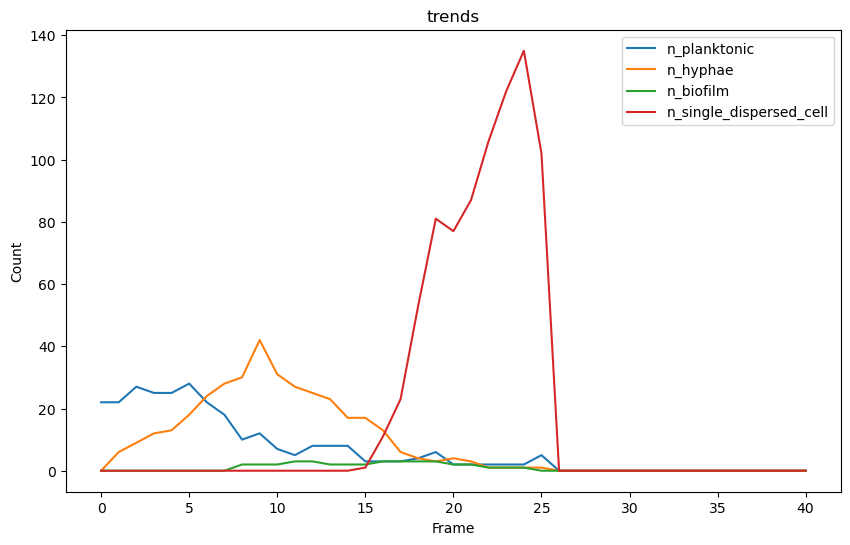

In [5]:
# visualize. line chart
label_cols = [c for c in df.columns if c not in ("frame", "n_total")]

plt.figure(figsize=(10,6))
for col in label_cols:
    plt.plot(df["frame"], df[col], label=col)

plt.xlabel("Frame")
plt.ylabel("Count")
plt.legend()
plt.title("trends")
plt.show()


#### Explore nd2 file

- We can use Fiji to transform nd2 file to tiff file. (or other files. There are lots of options)

In [6]:
file_path = "cellular-state-image-analysis/240922_mattLines.nd2"



(41, 1040, 1392) uint16


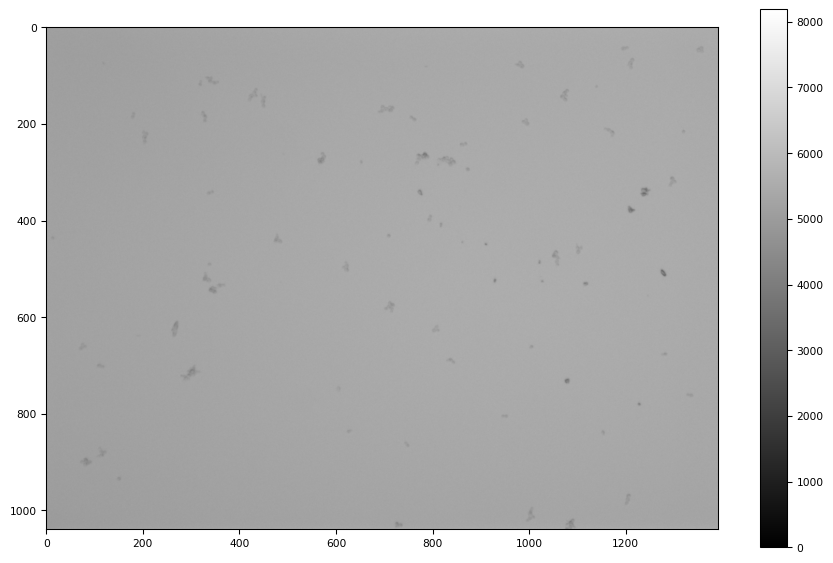

We have total frame 41
The width of the picture 1040
The height of the picture 1392


In [7]:
import tifffile as tiff
import numpy as np

images = tiff.imread("training.tif")
print(images.shape, images.dtype)

tiff.imshow(images[0], cmap="gray")
plt.show()

print("We have total frame", 41)
print("The width of the picture", 1040)
print("The height of the picture", 1392)

In [8]:
img0 = images[0]
img0

array([[5189, 5187, 5216, ..., 5439, 5635, 5627],
       [5103, 5168, 5038, ..., 5567, 5516, 5589],
       [5175, 5099, 5221, ..., 5607, 5581, 5471],
       ...,
       [5090, 5107, 5087, ..., 5481, 5427, 5404],
       [5105, 5140, 5144, ..., 5484, 5515, 5439],
       [5137, 5042, 5120, ..., 5509, 5467, 5490]], dtype=uint16)

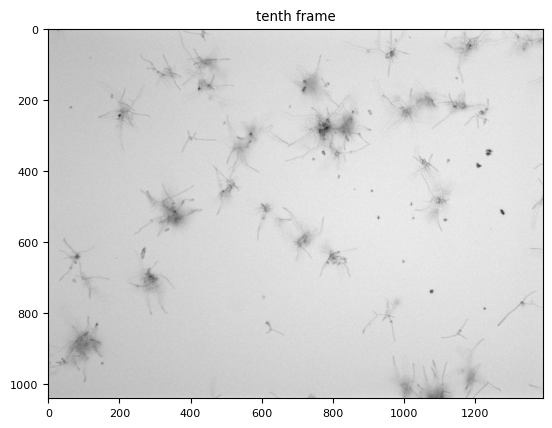

In [9]:
plt.imshow(images[10], cmap="gray")
plt.title("tenth frame")
plt.show()


#### Quick view and exploration of the brightness through time

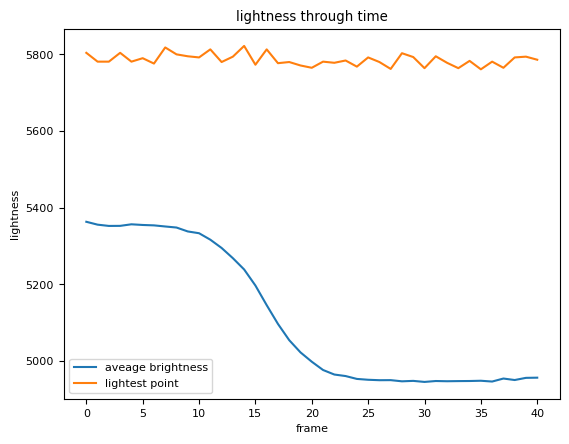

In [10]:
average_brightness = []   
max_brightness = []       

for frame in images:
    average_brightness.append(frame.mean()) # the mean value of each frame 
    max_brightness.append(frame.max()) # the max value of each frame

plt.plot(average_brightness, label="aveage brightness")
plt.plot(max_brightness, label="lightest point")
plt.xlabel("frame")
plt.ylabel("lightness")
plt.legend()
plt.title("lightness through time")
plt.show()


In [11]:
from sklearn.linear_model import LinearRegression
images_norm = images / 65535.0 ## normalize

T = images.shape[0]
y = images_norm.reshape(T, -1).mean(axis=1)   ## mean
t = np.arange(T).reshape(-1, 1)      ## time         

from sklearn.metrics import r2_score

model = LinearRegression().fit(t, y) # fit a simple linear regression
y_hat = model.predict(t)

slope = model.coef_[0]
intercept = model.intercept_
r2 = r2_score(y, y_hat)

print(f"slope for lightness = {slope:.3f}")
print(f"intercept = {intercept:.3f}")
print(f"R^2 = {r2:.3f}")


slope for lightness = -0.000
intercept = 0.082
R^2 = 0.845


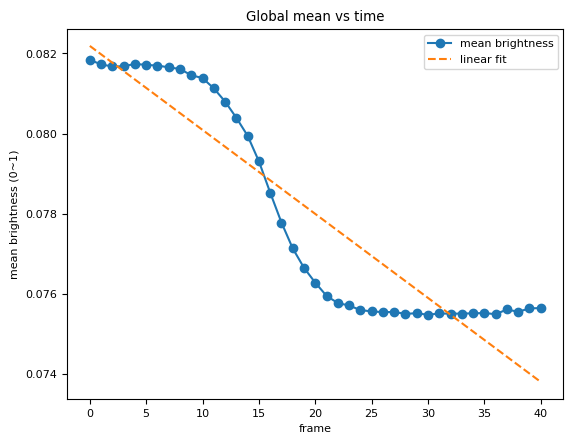

In [12]:
## see the trends of the expection of the brightness and fit a linear model
plt.plot(y, "o-", label="mean brightness")
plt.plot(y_hat, "--", label="linear fit")
plt.xlabel("frame"); plt.ylabel("mean brightness (0~1)")
plt.title("Global mean vs time")
plt.legend(); plt.show()


#### I want to extract all the cells that are ellipse shape first(planktonic) and see what is there gray_scale

- I also want to extract other shapes which coorsponding to other cell types

In [13]:
import cv2


# draw a mask for one of the ellipse for the frame0 
H, W = 1040, 1392
mask = np.zeros((H, W), dtype=np.uint8)
# from the xml we have 
cx, cy = 141.19, 102.60
rx, ry = 3.31, 3.78
angle = 0  

center = (int(round(cx)), int(round(cy)))
axes = (int(round(rx)), int(round(ry)))

cv2.ellipse(mask, center, axes, angle, 0, 360, 1, -1)
cv2.imwrite("mask_from_xml.png", mask * 255) # convert to white black 


True

##### For example,from xml:
ellipse frame="0" keyframe="1" outside="0" occluded="0" cx="141.19" cy="102.60" rx="3.31" ry="3.78" z_order="0"

In [14]:
# extract all the ellipse shape that are exist throughout the 41 frame and extract their coorsponding shape and position
frame_id = 0
ellipses_this_frame = []  
for track in root.findall("track"):
    label = track.attrib.get("label", "")
    for sh in track:
        if sh.tag == "ellipse" and sh.attrib.get("outside") == "0":
            f = int(sh.attrib["frame"])
            if f == frame_id:
                cx = float(sh.attrib["cx"]) 
                cy = float(sh.attrib["cy"]) 
                rx = float(sh.attrib["rx"]) 
                ry = float(sh.attrib["ry"])
                ellipses_this_frame.append((cx, cy, rx, ry, label))

ellipses_this_frame

[(141.19, 102.6, 3.31, 3.78, 'planktonic'),
 (146.4, 98.1, 4.73, 4.97, 'planktonic'),
 (98.74, 209.99, 3.51, 4.09, 'planktonic'),
 (96.69, 217.01, 4.38, 4.68, 'planktonic'),
 (176.92, 112.57, 4.31, 3.51, 'planktonic'),
 (171.53, 59.73, 4.31, 3.51, 'planktonic'),
 (164.25, 61.62, 4.58, 3.77, 'planktonic'),
 (66.11, 10.12, 5.12, 4.58, 'planktonic'),
 (83.33, 84.57, 4.9, 3.67, 'planktonic'),
 (58.83, 4.99, 3.77, 3.24, 'planktonic'),
 (88.23, 82.27, 4.29, 3.83, 'planktonic'),
 (92.36, 87.17, 4.44, 4.44, 'planktonic'),
 (85.63, 89.93, 3.52, 3.21, 'planktonic'),
 (74.91, 83.8, 4.44, 4.75, 'planktonic'),
 (75.06, 91.76, 4.59, 4.13, 'planktonic'),
 (71.24, 99.72, 4.44, 4.13, 'planktonic'),
 (133.37, 89.63, 3.93, 3.93, 'planktonic'),
 (127.52, 90.21, 3.26, 2.97, 'planktonic'),
 (124.17, 93.85, 4.69, 4.5, 'planktonic'),
 (116.8, 92.99, 4.02, 4.02, 'planktonic'),
 (139.21, 98.92, 3.06, 2.68, 'planktonic'),
 (142.61, 93.14, 3.78, 4.26, 'planktonic')]

##### For polyline 
polyline frame="6" keyframe="1" outside="0" occluded="0" points="158.25,84.36;158.25,93.33;150.65,105.28" z_order="0"

In [18]:
# come up with how to extract from one specific frame_id
frame_id = 20
polyline_this_frame = []
for track in root.findall("track"):
    label = track.attrib.get("label", "")
    for sh in track:
        if sh.tag.lower() == "polyline" and sh.attrib.get("outside", "0") == "0":
            f = int(sh.attrib["frame"])
            if f == frame_id:
                points_str = sh.attrib["points"]
                points = [tuple(map(float, pair.split(',')))
                          for pair in points_str.strip().split(';') if pair.strip()]
                polyline_this_frame.append((points, label))

polyline_this_frame


[([(65.3, 202.86), (63.81, 218.45), (71.24, 241.47)], 'hyphae'),
 ([(207.1, 27.66), (183.81, 0.0)], 'hyphae'),
 ([(218.9, 40.58), (212.1, 48.51), (210.22, 62.84)], 'hyphae'),
 ([(127.56, 33.16), (114.83, 22.97)], 'hyphae')]

In [25]:
T = 41

polylines_by_frame = {}  # frame_id -[(points, label), ...]

for frame_id in range(T):
    polyline_this_frame = []
    for track in root.findall("track"):
        label = track.attrib.get("label", "")
        for sh in track:
            if sh.tag.lower() == "polyline" and sh.attrib.get("outside", "0") == "0":
                f = int(sh.attrib["frame"])      
                if f == frame_id:
                    points_str = sh.attrib["points"]
                    points = [tuple(map(float, pair.split(',')))
                              for pair in points_str.strip().split(';') if pair.strip()]
                    polyline_this_frame.append((points, label))
    polylines_by_frame[frame_id] = polyline_this_frame

polylines_by_frame  


{0: [],
 1: [([(92.36, 81.36), (97.82, 77.54)], 'hyphae'),
  ([(91.27, 79.72), (89.63, 72.63)], 'hyphae'),
  ([(77.08, 83.82), (73.53, 74.81)], 'hyphae'),
  ([(73.8, 96.1), (64.52, 96.65)], 'hyphae'),
  ([(96.73, 89.0), (108.74, 89.55)], 'hyphae'),
  ([(74.07, 107.57), (71.62, 117.94)], 'hyphae')],
 2: [([(78.71, 97.64), (65.99, 99.32)], 'hyphae'),
  ([(78.71, 106.76), (73.19, 129.79)], 'hyphae'),
  ([(91.19, 97.16), (97.9, 104.84)], 'hyphae'),
  ([(101.5, 89.0), (123.82, 90.44)], 'hyphae'),
  ([(96.7, 79.65), (104.86, 69.33)], 'hyphae'),
  ([(93.11, 78.45), (83.03, 68.61)], 'hyphae'),
  ([(80.63, 85.4), (72.47, 68.61)], 'hyphae'),
  ([(148.05, 104.36), (141.09, 116.35)], 'hyphae'),
  ([(124.95, 146.83), (124.23, 140.25)], 'hyphae')],
 3: [([(119.74, 150.92), (108.3, 139.91)], 'hyphae'),
  ([(130.33, 163.21), (135.42, 165.33)], 'hyphae'),
  ([(145.28, 105.33), (136.95, 125.13)], 'hyphae'),
  ([(154.31, 89.01), (152.23, 79.28)], 'hyphae'),
  ([(103.6, 84.84), (133.47, 94.57)], 'hyphae')

In [29]:
import pandas as pd

rows = []
for frame, items in polylines_by_frame.items():
    for j, (pts, label) in enumerate(items):
        rows.append({
            "frame": frame,          
            "polyline_id": j,        
            "label": label,
            "n_points": len(pts),
            "points": pts           
        })

df = pd.DataFrame(rows).sort_values(["frame", "polyline_id"]).reset_index(drop=True)
df


,frame,polyline_id,label,n_points,points
0,1,0,hyphae,2,"[(92.36, 81.36), (97.82, 77.54)]"
1,1,1,hyphae,2,"[(91.27, 79.72), (89.63, 72.63)]"
2,1,2,hyphae,2,"[(77.08, 83.82), (73.53, 74.81)]"
3,1,3,hyphae,2,"[(73.8, 96.1), (64.52, 96.65)]"
4,1,4,hyphae,2,"[(96.73, 89.0), (108.74, 89.55)]"
...,...,...,...,...,...
354,21,2,hyphae,2,"[(162.8, 31.73), (163.15, 20.77)]"
355,22,0,hyphae,3,"[(214.26, 41.15), (208.27, 52.73), (201.09, 77..."
356,23,0,hyphae,3,"[(215.82, 40.77), (212.25, 50.14), (212.69, 63..."
357,24,0,hyphae,3,"[(216.87, 39.73), (211.61, 45.7), (209.5, 59.38)]"


In [30]:
ellipses_by_frame = {}  # frame_id - [(cx, cy, rx, ry, label), ...]

for frame_id in range(T):
    ellipses_this_frame = []
    for track in root.findall("track"):
        label = track.attrib.get("label", "")
        for sh in track:
            if sh.tag.lower() == "ellipse" and sh.attrib.get("outside", "0") == "0":
                f = int(sh.attrib["frame"])          
                if f == frame_id:
                    cx = float(sh.attrib["cx"])
                    cy = float(sh.attrib["cy"])
                    rx = float(sh.attrib["rx"])
                    ry = float(sh.attrib["ry"])
                    ellipses_this_frame.append((cx, cy, rx, ry, label))
    ellipses_by_frame[frame_id] = ellipses_this_frame

ellipses_by_frame  


{0: [(141.19, 102.6, 3.31, 3.78, 'planktonic'),
  (146.4, 98.1, 4.73, 4.97, 'planktonic'),
  (98.74, 209.99, 3.51, 4.09, 'planktonic'),
  (96.69, 217.01, 4.38, 4.68, 'planktonic'),
  (176.92, 112.57, 4.31, 3.51, 'planktonic'),
  (171.53, 59.73, 4.31, 3.51, 'planktonic'),
  (164.25, 61.62, 4.58, 3.77, 'planktonic'),
  (66.11, 10.12, 5.12, 4.58, 'planktonic'),
  (83.33, 84.57, 4.9, 3.67, 'planktonic'),
  (58.83, 4.99, 3.77, 3.24, 'planktonic'),
  (88.23, 82.27, 4.29, 3.83, 'planktonic'),
  (92.36, 87.17, 4.44, 4.44, 'planktonic'),
  (85.63, 89.93, 3.52, 3.21, 'planktonic'),
  (74.91, 83.8, 4.44, 4.75, 'planktonic'),
  (75.06, 91.76, 4.59, 4.13, 'planktonic'),
  (71.24, 99.72, 4.44, 4.13, 'planktonic'),
  (133.37, 89.63, 3.93, 3.93, 'planktonic'),
  (127.52, 90.21, 3.26, 2.97, 'planktonic'),
  (124.17, 93.85, 4.69, 4.5, 'planktonic'),
  (116.8, 92.99, 4.02, 4.02, 'planktonic'),
  (139.21, 98.92, 3.06, 2.68, 'planktonic'),
  (142.61, 93.14, 3.78, 4.26, 'planktonic')],
 1: [(73.93, 85.59, 2

In [32]:
rows = []
for frame, items in ellipses_by_frame.items():
    for j, (cx, cy, rx, ry, label) in enumerate(items):
        rows.append({
            "frame": frame,          
            "ellipse_id": j,         
            "label": label,
            "cx": float(cx),
            "cy": float(cy),
            "rx": float(rx),
            "ry": float(ry),
        })

df_ell = (pd.DataFrame(rows)
            .sort_values(["frame","ellipse_id"])
            .reset_index(drop=True))
print(df_ell)


      frame  ellipse_id                  label      cx      cy    rx    ry
0         0           0             planktonic  141.19  102.60  3.31  3.78
1         0           1             planktonic  146.40   98.10  4.73  4.97
2         0           2             planktonic   98.74  209.99  3.51  4.09
3         0           3             planktonic   96.69  217.01  4.38  4.68
4         0           4             planktonic  176.92  112.57  4.31  3.51
...     ...         ...                    ...     ...     ...   ...   ...
1074     25         102  single dispersed cell  116.09   76.38  3.86  3.04
1075     25         103  single dispersed cell  111.40   70.03  3.59  4.42
1076     25         104  single dispersed cell   98.43   65.62  4.42  3.31
1077     25         105  single dispersed cell   90.70   63.13  4.42  3.04
1078     25         106  single dispersed cell   95.39   60.10  2.48  3.31

[1079 rows x 7 columns]


In [34]:
# Again, first try to extract the gray for frame 1 then try to extract all of them through all frame at once
# for frame 1
ell0 = df_ell[df_ell["frame"] == 1].reset_index(drop=True)

# for tiff frame 1
img0 = tiff.imread("training.tif")[1].astype(np.float64)   

# ellipse central gray 
def center_pixel(image, cx, cy):
    xi, yi = int(round(cx)), int(round(cy))
    if 0 <= xi < image.shape[1] and 0 <= yi < image.shape[0]:
        return float(image[yi, xi])
    return np.nan

ell0["center_gray"] = [center_pixel(img0, cx, cy) for cx, cy in zip(ell0.cx, ell0.cy)]

# gray mean of the ellipse central
def ellipse_mean(image, cx, cy, rx, ry):
    H, W = image.shape
    x0 = max(int(np.floor(cx - rx)), 0); x1 = min(int(np.ceil(cx + rx)) + 1, W)
    y0 = max(int(np.floor(cy - ry)), 0); y1 = min(int(np.ceil(cy + ry)) + 1, H)
    if x1 <= x0 or y1 <= y0:
        return np.nan
    xs = np.arange(x0, x1); ys = np.arange(y0, y1)
    X, Y = np.meshgrid(xs, ys)
    inside = ((X - cx)**2)/(rx**2 + 1e-12) + ((Y - cy)**2)/(ry**2 + 1e-12) <= 1.0
    vals = image[y0:y1, x0:x1][inside]
    return float(vals.mean()) if vals.size else np.nan

ell0["mean_gray"] = [
    ellipse_mean(img0, cx, cy, rx, ry) for cx, cy, rx, ry in
    zip(ell0.cx, ell0.cy, ell0.rx, ell0.ry)
]

print(ell0)


    frame  ellipse_id       label      cx      cy    rx    ry  center_gray  \
0       1           0  planktonic   73.93   85.59  2.59  2.59       5147.0   
1       1           1  planktonic   89.21   94.73  2.87  3.00       5248.0   
2       1           2  planktonic   78.20   86.91  3.30  2.85       5082.0   
3       1           3  planktonic   88.54   89.31  3.44  2.85       5064.0   
4       1           4  planktonic   84.49   92.30  3.59  3.44       5070.0   
5       1           5  planktonic   91.23   84.81  3.44  3.44       5104.0   
6       1           6  planktonic   94.68   88.56  3.00  3.29       5120.0   
7       1           7  planktonic   76.14  103.57  3.94  4.44       5178.0   
8       1           8  planktonic  133.39   85.36  3.21  3.68       5047.0   
9       1           9  planktonic  137.21   86.74  3.68  4.14       5030.0   
10      1          10  planktonic  145.02   85.82  3.68  4.14       5116.0   
11      1          11  planktonic  148.81   93.29  3.33  4.02   

In [36]:
import numpy as np
import pandas as pd
import tifffile as tiff

images = tiff.imread("training.tif").astype(np.float64)  
if images.ndim == 2:  
    images = images[None, ...] # uniform the shape as THW
T, H, W = images.shape

# Copy the function again
def center_pixel(img, cx, cy):
    xi, yi = int(round(cx)), int(round(cy))
    if 0 <= xi < img.shape[1] and 0 <= yi < img.shape[0]:
        return float(img[yi, xi])
    return np.nan

def ellipse_mean(img, cx, cy, rx, ry):
    x0 = max(int(np.floor(cx - rx)), 0); x1 = min(int(np.ceil(cx + rx)) + 1, img.shape[1])
    y0 = max(int(np.floor(cy - ry)), 0); y1 = min(int(np.ceil(cy + ry)) + 1, img.shape[0])
    if x1 <= x0 or y1 <= y0:
        return np.nan
    xs = np.arange(x0, x1); ys = np.arange(y0, y1)
    X, Y = np.meshgrid(xs, ys)
    inside = ((X - cx)**2)/(rx**2 + 1e-12) + ((Y - cy)**2)/(ry**2 + 1e-12) <= 1.0
    vals = img[y0:y1, x0:x1][inside]
    return float(vals.mean()) if vals.size else np.nan

# Main
rows = []
for r in df_ell.itertuples(index=False):
    f = int(r.frame)
    if not (0 <= f < T):
        rows.append({
            "frame": r.frame, "ellipse_id": r.ellipse_id, "label": r.label,
            "cx": r.cx, "cy": r.cy, "rx": r.rx, "ry": r.ry,
            "center_gray": np.nan, "mean_gray": np.nan
        })
        continue

    img = images[f]
    cg = center_pixel(img, r.cx, r.cy)
    mg = ellipse_mean(img, r.cx, r.cy, r.rx, r.ry)

    rows.append({
        "frame": r.frame, "ellipse_id": r.ellipse_id, "label": r.label,
        "cx": r.cx, "cy": r.cy, "rx": r.rx, "ry": r.ry,
        "center_gray": cg, "mean_gray": mg
    })

df_ell_gray = (pd.DataFrame(rows)
               .sort_values(["frame","ellipse_id"])
               .reset_index(drop=True))

print(df_ell_gray, "\nshape:", df_ell_gray.shape)


      frame  ellipse_id                  label      cx      cy    rx    ry  \
0         0           0             planktonic  141.19  102.60  3.31  3.78   
1         0           1             planktonic  146.40   98.10  4.73  4.97   
2         0           2             planktonic   98.74  209.99  3.51  4.09   
3         0           3             planktonic   96.69  217.01  4.38  4.68   
4         0           4             planktonic  176.92  112.57  4.31  3.51   
...     ...         ...                    ...     ...     ...   ...   ...   
1074     25         102  single dispersed cell  116.09   76.38  3.86  3.04   
1075     25         103  single dispersed cell  111.40   70.03  3.59  4.42   
1076     25         104  single dispersed cell   98.43   65.62  4.42  3.31   
1077     25         105  single dispersed cell   90.70   63.13  4.42  3.04   
1078     25         106  single dispersed cell   95.39   60.10  2.48  3.31   

      center_gray    mean_gray  
0          5112.0  5144.219512

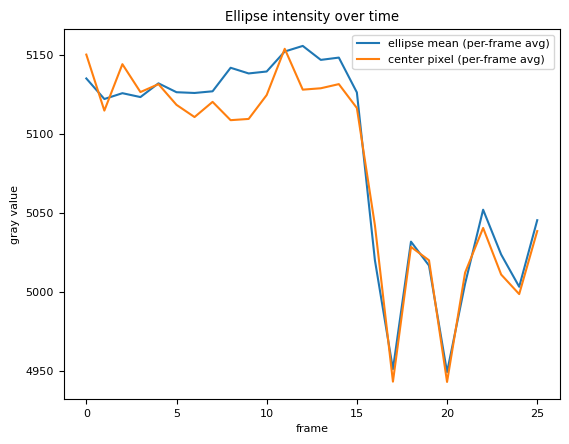

In [40]:
per_frame = (df_ell_gray.groupby("frame")[["center_gray","mean_gray"]]
             .mean())

plt.plot(per_frame.index, per_frame["mean_gray"], label="ellipse mean (per-frame avg)")
plt.plot(per_frame.index, per_frame["center_gray"], label="center pixel (per-frame avg)")
plt.xlabel("frame")
plt.ylabel("gray value")
plt.title("Ellipse intensity over time")
plt.legend()
plt.show()


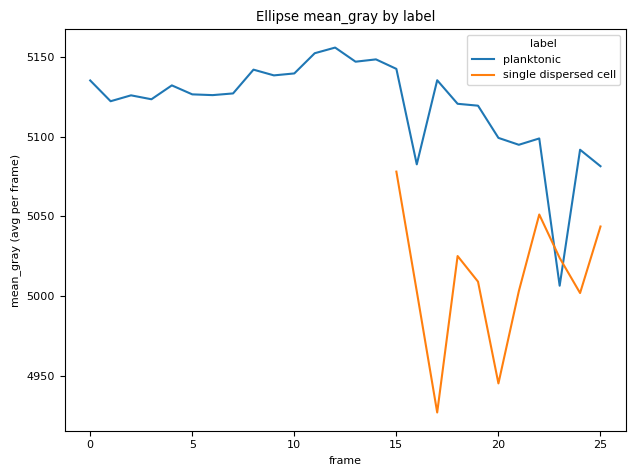

In [39]:
per_frame_label = (df_ell_gray
                   .groupby(["frame","label"])["mean_gray"]
                   .mean()
                   .unstack(fill_value=float("nan")))

per_frame_label.plot()
plt.xlabel("frame"); plt.ylabel("mean_gray (avg per frame)")
plt.title("Ellipse mean_gray by label")
plt.tight_layout()
plt.show()


In [41]:
import numpy as np
import pandas as pd
import tifffile as tiff

# 读 tiff（T, H, W）
images = tiff.imread("training.tif").astype(np.float64)   # 改成你的路径
if images.ndim == 2:
    images = images[None, ...]
T, H, W = images.shape

# ---- 工具函数：双线性插值取一个浮点坐标的灰度 ----
def bilinear_sample(image, x, y):
    H, W = image.shape
    if x < 0 or y < 0 or x >= W - 1 or y >= H - 1:
        return np.nan
    x0 = int(np.floor(x)); y0 = int(np.floor(y))
    dx = x - x0; dy = y - y0
    I00 = image[y0,     x0    ]
    I10 = image[y0,     x0 + 1]
    I01 = image[y0 + 1, x0    ]
    I11 = image[y0 + 1, x0 + 1]
    return float(I00*(1-dx)*(1-dy) + I10*dx*(1-dy) + I01*(1-dx)*dy + I11*dx*dy)

# ---- 沿 polyline 各段以~1像素步长采样，返回该条折线的所有采样灰度 ----
def sample_polyline(image, pts, step=1.0):
    vals = []
    if len(pts) < 1:
        return vals
    for (x0, y0), (x1, y1) in zip(pts[:-1], pts[1:]):
        dx, dy = (x1 - x0), (y1 - y0)
        L = max(abs(dx), abs(dy))  # 替代长度，保证大概每像素取一次
        n = int(np.ceil(L / step)) if L > 0 else 1
        for i in range(n + 1):
            t = i / max(n, 1)
            x = x0 + t * dx
            y = y0 + t * dy
            vals.append(bilinear_sample(image, x, y))
    # 去掉 NaN
    return [v for v in vals if np.isfinite(v)]


In [42]:
rows = []
for r in df_poly.itertuples(index=False):
    f = int(r.frame)
    if not (0 <= f < T):
        rows.append({
            "frame": r.frame, "polyline_id": r.polyline_id, "label": r.label,
            "n_points": len(r.points),
            "n_samples": 0, "mean_gray": np.nan, "median_gray": np.nan,
            "std_gray": np.nan, "p90_gray": np.nan
        })
        continue

    img = images[f]
    vals = sample_polyline(img, r.points, step=1.0)   # 采样步长可调
    if len(vals) == 0:
        rows.append({
            "frame": r.frame, "polyline_id": r.polyline_id, "label": r.label,
            "n_points": len(r.points),
            "n_samples": 0, "mean_gray": np.nan, "median_gray": np.nan,
            "std_gray": np.nan, "p90_gray": np.nan
        })
    else:
        vals_arr = np.array(vals, dtype=float)
        rows.append({
            "frame": r.frame, "polyline_id": r.polyline_id, "label": r.label,
            "n_points": len(r.points),
            "n_samples": int(vals_arr.size),
            "mean_gray": float(vals_arr.mean()),
            "median_gray": float(np.median(vals_arr)),
            "std_gray": float(vals_arr.std()),
            "p90_gray": float(np.percentile(vals_arr, 90)),
        })

df_poly_gray = (pd.DataFrame(rows)
                .sort_values(["frame","polyline_id"])
                .reset_index(drop=True))

print(df_poly_gray.head(), "\nshape:", df_poly_gray.shape)


NameError: name 'df_poly' is not defined